In [1]:
from collections import defaultdict
from dataclasses import dataclass
import itertools
import os
import typing
import warnings

from gliner_spacy.pipeline import GlinerSpacy
from icecream import ic
from pydantic import BaseModel
from pyinstrument import Profiler
import glirel
import matplotlib
import matplotlib.colors
import networkx as nx
import pandas as pd
import pyvis
import spacy
import transformers

In [2]:
transformers.logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "0"

In [3]:
profiler: Profiler = Profiler()
profiler.start()

In [4]:
CHUNK_SIZE: int = 1024

GLINER_MODEL: str = "urchade/gliner_multi-v2.1"

NER_LABELS: typing.List[ str] = [
    "Behavior",
    "City",
    "Company",
    "Condition",
    "Conference",
    "Country",
    "Food",
    "Food Additive",
    "Hospital",
    "Organ",
    "Organization",
    "People Group",
    "Person",
    "Publication",
    "Research",
    "Science",
    "University",
]

RE_LABELS: dict = {
    "glirel_labels": {
        "no_relation": {},
        "co_founder": {"allowed_head": ["PERSON"], "allowed_tail": ["ORG"]},
        "country_of_origin": {"allowed_head": ["PERSON", "ORG"], "allowed_tail": ["LOC", "GPE"]},
        "parent": {"allowed_head": ["PERSON"], "allowed_tail": ["PERSON"]},
        "followed_by": {"allowed_head": ["PERSON", "ORG"], "allowed_tail": ["PERSON", "ORG"]},
        "spouse": {"allowed_head": ["PERSON"], "allowed_tail": ["PERSON"]},
        "child": {"allowed_head": ["PERSON"], "allowed_tail": ["PERSON"]},
        "founder": {"allowed_head": ["PERSON"], "allowed_tail": ["ORG"]},
        "headquartered_in": {"allowed_head": ["ORG"], "allowed_tail": ["LOC", "GPE", "FAC"]},
        "acquired_by": {"allowed_head": ["ORG"], "allowed_tail": ["ORG", "PERSON"]},
        "subsidiary_of": {"allowed_head": ["ORG"], "allowed_tail": ["ORG", "PERSON"]},
    }
}

SPACY_MODEL: str = "en_core_web_md"

STOP_WORDS: typing.Set[ str ] = set([
    "PRON.it",
    "PRON.that",
    "PRON.they",
    "PRON.those",
    "PRON.we",
    "PRON.which",
    "PRON.who",
])

TR_ALPHA: float = 0.85
TR_LOOKBACK: int = 3

In [5]:
nlp: spacy.Language = spacy.load(SPACY_MODEL)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    nlp.add_pipe(
        "gliner_spacy",
        config = {
            "gliner_model": GLINER_MODEL,
            "labels": NER_LABELS,
            "chunk_size": CHUNK_SIZE,
            "style": "ent",
        },
    )

    nlp.add_pipe(
        "glirel",
        after = "ner",
    );

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

glirel_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/874M [00:00<?, ?B/s]

In [6]:
graph: nx.Graph = nx.Graph()
known_lemma: typing.List[ str ] = [] 

In [8]:
class TextChunk (BaseModel):
    uid: int
    url: str
    text: str

SAMPLE_CHUNK: TextChunk = TextChunk(
    uid = 1,
    url = "https://www.theguardian.com/society/article/2024/jul/31/eating-processed-red-meat-could-increase-risk-of-dementia-study-finds",
    text = """
Sistem Rekomendasi Tempat Wisata Di Gresik Dengan Implementasi Algoritma Machine Learning. 
Pariwisata di Kabupaten Gresik mengalami perkembangan pesat. Banyak wisatawan kesulitan menentukan destinasi yang sesuai dengan preferensi mereka. Penelitian ini bertujuan membangun sistem rekomendasi berbasis Android menggunakan metode Content-Based Filtering. Algoritma ini merekomendasikan tempat wisata baru berdasarkan kemiripan atribut dengan tempat wisata yang pernah dikunjungi pengguna sebelumnya. Pengujian sistem Black Box menunjukkan bahwa seluruh fungsionalitas berjalan 100% dengan baik. Hasil eksperimen menggunakan matrik precision membuktikan bahwa model Content-Based Filtering mampu memberikan rekomendasi yang sangat akurat.
"""
)

chunk: TextChunk = SAMPLE_CHUNK

In [9]:
doc: spacy.tokens.doc.Doc = list(
    nlp.pipe(
        [( chunk.text, RE_LABELS )],
        as_tuples = True,
    )
)[0][0]

In [11]:
from nltk.tree import Tree

def to_nltk_tree (node):
    if node.n_lefts + node.n_rights > 0:
        return Tree(node.orth_, [to_nltk_tree(child) for child in node.children])
    else:
        return node.orth_

[to_nltk_tree(sent.root).pretty_print() for sent in doc.sents]

                                     Learning                                   
      __________________________________|_____________________________________   
     |          |        |      |             Implementasi                    | 
     |          |        |      |        __________|________________          |  
     |          |        |    Sistem    |          |              Gresik      . 
     |          |        |      |       |          |          ______|_____    |  
Rekomendasi Algoritma Machine         Tempat     Dengan    Wisata         Di    
                                                                                

               pesat                        
  _______________|___________________        
 |             Gresik           perkembangan
 |       ________|________           |       
 .  Pariwisata   di   Kabupaten  mengalami  

                        mereka                             
   _______________________|____________________________     

[None, None, None, None, None, None, None]

In [12]:
for sent in doc.sents:
    node_seq: typing.List[ int ] = []
    ic(sent)

    for tok in sent:
        text: str = tok.text.strip()

        if tok.pos_ in [ "NOUN", "PROPN" ]:
            key: str = tok.pos_ + "." + tok.lemma_.strip().lower()
            print(tok.i, key, tok.text.strip())

            if key not in known_lemma:
                # create a new node
                known_lemma.append(key)
                node_id: int = known_lemma.index(key)
                node_seq.append(node_id)

                graph.add_node(
                    node_id,
                    key = key,
                    kind = "Lemma",
                    pos = tok.pos_,
                    text = text,
                    chunk = chunk.uid,
                    count = 1,
                )
            else:
                # link to an existing node, adding weight
                node_id = known_lemma.index(key)
                node_seq.append(node_id)

                node: dict = graph.nodes[node_id]
                node["count"] += 1

    # create the textrank edges
    ic(node_seq)

    for hop in range(TR_LOOKBACK):
        for node_id, node in enumerate(node_seq[: -1 - hop]):
            neighbor: int = node_seq[hop + node_id + 1]
            graph.add_edge(
                node,
                neighbor,
                rel = "FOLLOWS_LEXICALLY",
            )

ic| sent: 
          Sistem Rekomendasi Tempat Wisata Di Gresik Dengan Implementasi Algoritma Machine Learning. 
ic| node_seq: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


1 PROPN.sistem Sistem
2 PROPN.rekomendasi Rekomendasi
3 PROPN.tempat Tempat
4 PROPN.wisata Wisata
5 PROPN.di Di
6 PROPN.gresik Gresik
7 PROPN.dengan Dengan
8 PROPN.implementasi Implementasi
9 PROPN.algoritma Algoritma
10 PROPN.machine Machine
11 PROPN.learning Learning


ic| sent: Pariwisata di Kabupaten Gresik mengalami perkembangan pesat.
ic| node_seq: [11, 12, 13, 5, 14]
ic| sent: Banyak wisatawan kesulitan menentukan destinasi yang sesuai dengan preferensi

14 PROPN.pariwisata Pariwisata
15 NOUN.di di
16 PROPN.kabupaten Kabupaten
17 PROPN.gresik Gresik
19 NOUN.perkembangan perkembangan


 mereka.
ic| node_seq: [15, 16, 17, 18, 19, 20, 21, 6, 22, 23]


...

48 PROPN.algoritma Algoritma
49 PROPN.ini ini
50 PROPN.merekomendasikan merekomendasikan
51 PROPN.tempat tempat
52 PROPN.wisata wisata
53 PROPN.baru baru
54 PROPN.berdasarkan berdasarkan
55 PROPN.kemiripan kemiripan
56 PROPN.atribut atribut
57 PROPN.dengan dengan
58 PROPN.tempat tempat
59 PROPN.wisata wisata
60 PROPN.yang yang
61 PROPN.pernah pernah
62 PROPN.dikunjungi dikunjungi
63 PROPN.pengguna pengguna
64 NOUN.sebelumnya sebelumnya


41]
ic| sent: Pengujian sistem Black Box menunjukkan bahwa seluruh fungsionalitas berjalan 100% dengan baik.
ic| node_seq: 

67 NOUN.sistem sistem
68 PROPN.black Black
69 PROPN.box Box
71 PROPN.bahwa bahwa
72 NOUN.seluruh seluruh
73 NOUN.fungsionalita fungsionalitas
76 NOUN.% %
77 PROPN.dengan dengan
78 PROPN.baik baik


[42, 43, 44, 45, 46, 47, 48, 6, 49]
ic| sent: Hasil eksperimen menggunakan matrik precision membuktikan bahwa model Content-Based Filtering mampu memberikan rekomendasi yang sangat akurat.
ic| node_seq: [50, 51, 29, 52, 53, 54, 45, 55, 31, 32, 56, 57, 1, 20, 58, 59]


80 PROPN.hasil Hasil
81 PROPN.eksperimen eksperimen
82 PROPN.menggunakan menggunakan
83 PROPN.matrik matrik
84 PROPN.precision precision
85 PROPN.membuktikan membuktikan
86 PROPN.bahwa bahwa
87 PROPN.model model
88 PROPN.content Content
91 PROPN.filtering Filtering
92 PROPN.mampu mampu
93 PROPN.memberikan memberikan
94 PROPN.rekomendasi rekomendasi
95 PROPN.yang yang
96 PROPN.sangat sangat
97 PROPN.akurat akurat


In [13]:
sent_map: typing.Dict[ spacy.tokens.span.Span, int ] = {}

for sent_id, sent in enumerate(doc.sents):
    sent_map[sent] = sent_id

In [14]:
@dataclass(order=False, frozen=False)
class Entity:
    loc: typing.Tuple[ int ]
    key: str
    text: str
    label: str
    chunk_id: int
    sent_id: int
    span: spacy.tokens.span.Span
    node: typing.Optional[ int ] = None


span_decoder: typing.Dict[ tuple, Entity ] = {}


def make_entity (
    span: spacy.tokens.span.Span,
    chunk: TextChunk,
    ) -> Entity:
    """
Instantiate one `Entity` dataclass object, adding it to the working "vocabulary".
    """
    key: str = " ".join([
        tok.pos_ + "." + tok.lemma_.strip().lower()
        for tok in span
    ])

    ent: Entity = Entity(
        ( span.start, span.end, ),
        key,
        span.text,
        span.label_,
        chunk.uid,
        sent_map[span.sent],
        span,
    )

    if ent.loc not in span_decoder:
        span_decoder[ent.loc] = ent
        ic(ent)

    return ent

In [15]:
for span in doc.ents:
    make_entity(span, chunk)

for span in doc.noun_chunks:
    make_entity(span, chunk)

ic| ent: Entity(loc=(0, 12),
                key='SPACE. PROPN.sistem PROPN.rekomendasi PROPN.tempat PROPN.wisata '
                    'PROPN.di PROPN.gresik PROPN.dengan PROPN.implementasi '
                    'PROPN.algoritma PROPN.machine PROPN.learning',
                text='
         '
                     'Sistem Rekomendasi Tempat Wisata Di Gresik Dengan Implementasi '
                     'Algoritma Machine Learning',
                label='NP',
                chunk_id=1,
                sent_id=0,
                span=
         Sistem Rekomendasi Tempat Wisata Di Gresik Dengan Implementasi Algoritma Machine Learning,
                node=None)
ic| ent: Entity(loc=(14, 18),
                key='PROPN.pariwisata NOUN.di PROPN.kabupaten PROPN.gresik',
                text='Pariwisata di Kabupaten Gresik',
                label='NP',
                chunk_id=1,
                sent_id=1,
                span=Pariwisata di Kabupaten Gresik,
                node=None)
ic| ent: E

In [16]:
def extract_entity (
    ent: Entity,
    ) -> None:
    """
Link one `Entity` into the existing graph.
    """
    if ent.key not in known_lemma:
        # add a new Entity node to the graph and link to its component Lemma nodes
        known_lemma.append(ent.key)
        node_id: int = known_lemma.index(ent.key)

        graph.add_node(
            node_id,
            key = ent.key,
            kind = "Entity",
            label = ent.label,
            pos = "NP",
            text = ent.text,
            chunk = ent.chunk_id,
            count = 1,
        )

        for tok in ent.span:
            tok_key: str = tok.pos_ + "." + tok.lemma_.strip().lower()

            if tok_key in known_lemma:
                tok_idx: int = known_lemma.index(tok_key)

                graph.add_edge(
                    node_id,
                    tok_idx,
                    rel = "COMPOUND_ELEMENT_OF",
                )
    else:
        node_id: int = known_lemma.index(ent.key)
        node: dict = graph.nodes[node_id]
        # promote to an Entity, in case the node had been a Lemma
        node["kind"] = "Entity"
        node["chunk"] = ent.chunk_id
        node["count"] += 1

        # select the more specific label
        if "label" not in node or node["label"] == "NP":
          node["label"] = ent.label

    ent.node = node_id

In [17]:
for ent in span_decoder.values():
    if ent.key not in STOP_WORDS:
        extract_entity(ent)
        ic(ent)

ic| ent: Entity(loc=(0, 12),
                key='SPACE. PROPN.sistem PROPN.rekomendasi PROPN.tempat PROPN.wisata '
                    'PROPN.di PROPN.gresik PROPN.dengan PROPN.implementasi '
                    'PROPN.algoritma PROPN.machine PROPN.learning',
                text='
         '
                     'Sistem Rekomendasi Tempat Wisata Di Gresik Dengan Implementasi '
                     'Algoritma Machine Learning',
                label='NP',
                chunk_id=1,
                sent_id=0,
                span=
         Sistem Rekomendasi Tempat Wisata Di Gresik Dengan Implementasi Algoritma Machine Learning,
                node=60)
ic| ent: Entity(loc=(14, 18),
                key='PROPN.pariwisata NOUN.di PROPN.kabupaten PROPN.gresik',
                text='Pariwisata di Kabupaten Gresik',
                label='NP',
                chunk_id=1,
                sent_id=1,
                span=Pariwisata di Kabupaten Gresik,
                node=61)
ic| ent: Entit

In [18]:
relations: typing.List[ dict ] = sorted(
    doc._.relations,
    key = lambda x: x["score"],
    reverse = True,
)

for item in relations:
    src_loc: typing.Tuple[ int ] = tuple(item["head_pos"])
    dst_loc: typing.Tuple[ int ] = tuple(item["tail_pos"])
    skip_rel: bool = False

    if src_loc not in span_decoder:
        print("MISSING src entity:", item["head_text"], item["head_pos"])

        src_ent: Entity = make_entity(
            doc[ item["head_pos"][0] : item["head_pos"][1] ],
            chunk,
        )

        if src_ent.key in STOP_WORDS:
            skip_rel = True
        else:
            extract_entity(src_ent)

    if dst_loc not in span_decoder:
        print("MISSING dst entity:", item["tail_text"], item["tail_pos"])

        dst_ent: Entity = make_entity(
            doc[ item["tail_pos"][0] : item["tail_pos"][1] ],
            chunk,
        )

        if dst_ent.key in STOP_WORDS:
            skip_rel = True
        else:
            extract_entity(dst_ent)

    # link the connected nodes
    if not skip_rel:
        src_ent = span_decoder[src_loc]
        dst_ent = span_decoder[dst_loc]

        rel: str = item["label"].strip().replace(" ", "_").upper()
        prob: float = round(item["score"], 3)

        print(f"{src_ent.text} {src_ent.node} -> {rel} -> {dst_ent.text} {dst_ent.node} | {prob}")

        graph.add_edge(
            src_ent.node,
            dst_ent.node,
            rel = rel,
            prob = prob,
        )

In [19]:
ent_map: typing.Dict[ int, typing.Set[ int ]] = defaultdict(set)

for ent in span_decoder.values():
    if ent.node is not None:
        ent_map[ent.sent_id].add(ent.node)

for sent_id, nodes in ent_map.items():
    for pair in itertools.combinations(list(nodes), 2):
        if not graph.has_edge(*pair):
            graph.add_edge(
                pair[0],
                pair[1],
                rel = "CO_OCCURS_WITH",
                prob = 1.0,
            )

In [20]:
for node, rank in nx.pagerank(graph, alpha = TR_ALPHA, weight = "count").items():
    graph.nodes[node]["rank"] = rank

In [21]:
df: pd.DataFrame = pd.DataFrame([
    node_attr
    for node, node_attr in graph.nodes(data = True)
    if node_attr["kind"] == "Entity"
]).sort_values(by = [ "rank", "count" ], ascending = False)

df.head(20)

,key,kind,label,pos,text,chunk,count,rank
13,PROPN.hasil PROPN.eksperimen PROPN.menggunakan...,Entity,NP,NP,Hasil eksperimen menggunakan matrik precision ...,1,1,0.025648
9,PROPN.atribut PROPN.dengan PROPN.tempat PROPN....,Entity,NP,NP,atribut dengan tempat wisata yang pernah dikun...,1,1,0.018429
0,SPACE. PROPN.sistem PROPN.rekomendasi PROPN.te...,Entity,NP,NP,\nSistem Rekomendasi Tempat Wisata Di Gresik D...,1,1,0.018206
3,PROPN.banyak PROPN.wisatawan PROPN.kesulitan P...,Entity,NP,NP,Banyak wisatawan kesulitan menentukan destinas...,1,1,0.018070
6,PROPN.android PROPN.menggunakan PROPN.metode P...,Entity,NP,NP,Android menggunakan metode Content-Based Filte...,1,1,0.012585
1,PROPN.pariwisata NOUN.di PROPN.kabupaten PROPN...,Entity,NP,NP,Pariwisata di Kabupaten Gresik,1,1,0.012581
8,PROPN.tempat PROPN.wisata PROPN.baru PROPN.ber...,Entity,NP,NP,tempat wisata baru berdasarkan kemiripan,1,1,0.012110
10,ADJ.pengujian NOUN.sistem PROPN.black PROPN.box,Entity,NP,NP,Pengujian sistem Black Box,1,1,0.011086
12,NUM.100 NOUN.% PROPN.dengan PROPN.baik,Entity,NP,NP,100% dengan baik,1,1,0.010558
11,VERB.menunjukkan PROPN.bahwa NOUN.seluruh NOUN...,Entity,NP,NP,menunjukkan bahwa seluruh fungsionalitas,1,1,0.010477


In [22]:
pv_net: pyvis.network.Network = pyvis.network.Network(
    height = "750px",
    width = "100%",
    notebook = True,
    cdn_resources = "remote",
)

for node_id, node_attr in graph.nodes(data = True):
    if node_attr["kind"] == "Entity":
        color: str = "hsl(65, 46%, 58%)"
        size: int = round(200 * node_attr["rank"])
    else:
        color = "hsla(72, 10%, 90%, 0.95)"
        size = round(30 * node_attr["rank"])

    pv_net.add_node(
        node_id,
        label = node_attr["text"],
        title = node_attr.get("label"),
        color = color,
        size = size,
    )

for src_node, dst_node, edge_attr in graph.edges(data = True):
    pv_net.add_edge(
        src_node,
        dst_node,
        title = edge_attr.get("rel"),
    )

pv_net.toggle_physics(True)
pv_net.show("chunk.html")

chunk.html


In [23]:
from IPython.display import IFrame

# Menampilkan file HTML dalam ukuran 800x600 piksel di dalam notebook
IFrame(src='./chunk.html', width='100%', height='600px')


In [ ]:
communities: typing.Generator = nx.community.louvain_communities(graph)

comm_map: typing.Dict[ int, int ] = {
    node_id: i
    for i, comm in enumerate(communities)
    for node_id in comm
}

xkcd_colors: typing.List[ str ] = list(matplotlib.colors.XKCD_COLORS.values())

colors: typing.List[ str ] = [
    xkcd_colors[comm_map[n]]
    for n in list(graph.nodes())
]

labels: typing.Dict[ int, str ] = {
    node_id: node_attr["text"]
    for node_id, node_attr in graph.nodes(data = True)
}

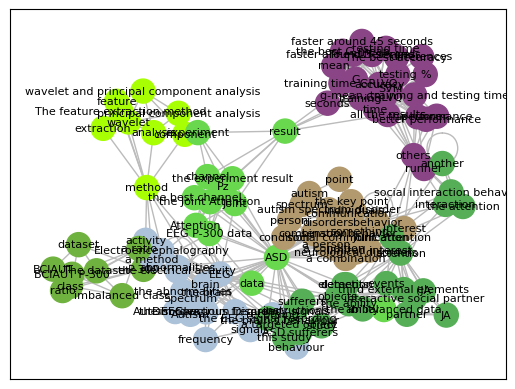

In [ ]:
SPRING_DISTANCE: float = 2.5

nx.draw_networkx(
    graph,
    pos = nx.spring_layout(
        graph,
        k = SPRING_DISTANCE / len(communities),
    ),
    labels = labels,
    node_color = colors,
    edge_color = "#bbb",
    with_labels = True,
    font_size = 8,
)

In [ ]:
ic(len(known_lemma))
ic(len(span_decoder))
ic(len(graph.nodes()));

ic| len(known_lemma): 120
ic| len(span_decoder): 91
ic| len(graph.nodes()): 120


In [ ]:
profiler.stop()
profiler.print()


  _     ._   __/__   _ _  _  _ _/_   Recorded: 09:01:12  Samples:  185657
 /_//_/// /_\ / //_// / //_'/ //     Duration: 644.607   CPU time: 224.970
/   _/                      v5.1.1

Profile at /tmp/ipython-input-382364451.py:2

644.603 _UnixSelectorEventLoop._run_once  asyncio/base_events.py:1922
├─ 380.710 EpollSelector.select  selectors.py:451
│  └─ 380.709 epoll.poll  <built-in>
└─ 263.892 Handle._run  asyncio/events.py:86
      [10 frames hidden]  ipykernel, IPython
         261.579 Shell.run_ast_nodes  IPython/core/interactiveshell.py:3360
         └─ 249.688 <cell line: 0>  ../ipython-input-2312294158.py:1
            └─ 247.227 English.add_pipe  spacy/language.py:768
                  [116 frames hidden]  spacy, confection, glirel, huggingfac...




In [ ]:
for x in known_lemma:
    if "PRON" in x:
        print(x)

PRON.something
PRON.another


In [ ]:
kept_nodes: typing.Set[ int ] = set()

for node_id, node_attr in graph.nodes(data = True):
    if node_attr["kind"] == "Entity":
        print(node_id, node_attr["key"], node_attr["rank"], node_attr["label"], node_attr["text"], node_attr["chunk"])
        kept_nodes.add(node_id)

0 PROPN.electroencephalography 0.007584623378317129 NP Electroencephalography 1
1 PROPN.eeg 0.022849322361464256 Science EEG 1
4 NOUN.brain 0.018759112631316247 Organ brain 1
12 PROPN.asd 0.040924633969153947 Organ ASD 1
18 NOUN.behavior 0.015013401038054146 NP behavior 1
20 NOUN.attention 0.0163752476249928 NP attention 1
25 NOUN.object 0.013962511551112791 NP objects 1
26 NOUN.event 0.008210400284285458 NP events 1
28 NOUN.other 0.014720914678458548 NP others 1
30 NOUN.individual 0.009840597659157554 NP individuals 1
33 NOUN.study 0.00834461891976878 Research study 1
36 NOUN.instruction 0.010692291615690144 NP instructions 1
46 NOUN.wavelet 0.010404840088572651 Science wavelet 1
51 PROPN.pz 0.010052348612204984 NP Pz 1
55 NOUN.accuracy 0.017990530168591902 NP accuracy 1
56 PROPN.grlvq 0.015458897940172963 NP GRLVQ 1
59 PROPN.svm 0.01798254868922371 NP SVM 1
68 PROPN.autism PROPN.spectrum PROPN.disorder 0.008151187199518871 Condition Autism Spectrum Disorder 1
69 ADJ.social NOUN.commu

In [ ]:
skip_rel: typing.Set[ str ] = set([ "FOLLOWS_LEXICALLY", "COMPOUND_ELEMENT_OF" ])

for src_id, dst_id, edge_attr in graph.edges(data = True):
    if src_id in kept_nodes and dst_id in kept_nodes:
        rel: str = edge_attr["rel"]

        if rel not in skip_rel:
            print(src_id, dst_id, rel, edge_attr["prob"])

0 4 CO_OCCURS_WITH 1.0
0 74 CO_OCCURS_WITH 1.0
0 75 CO_OCCURS_WITH 1.0
0 76 CO_OCCURS_WITH 1.0
1 74 CO_OCCURS_WITH 1.0
1 75 CO_OCCURS_WITH 1.0
1 76 CO_OCCURS_WITH 1.0
1 68 CO_OCCURS_WITH 1.0
1 79 CO_OCCURS_WITH 1.0
4 74 CO_OCCURS_WITH 1.0
4 75 CO_OCCURS_WITH 1.0
4 77 CO_OCCURS_WITH 1.0
4 68 CO_OCCURS_WITH 1.0
4 12 CO_OCCURS_WITH 1.0
4 79 CO_OCCURS_WITH 1.0
12 68 CO_OCCURS_WITH 1.0
12 76 CO_OCCURS_WITH 1.0
12 79 CO_OCCURS_WITH 1.0
12 69 CO_OCCURS_WITH 1.0
12 70 CO_OCCURS_WITH 1.0
12 80 CO_OCCURS_WITH 1.0
12 81 CO_OCCURS_WITH 1.0
12 82 CO_OCCURS_WITH 1.0
12 83 CO_OCCURS_WITH 1.0
12 18 CO_OCCURS_WITH 1.0
12 84 CO_OCCURS_WITH 1.0
12 85 CO_OCCURS_WITH 1.0
12 71 CO_OCCURS_WITH 1.0
12 72 CO_OCCURS_WITH 1.0
12 93 CO_OCCURS_WITH 1.0
12 30 CO_OCCURS_WITH 1.0
12 96 CO_OCCURS_WITH 1.0
12 97 CO_OCCURS_WITH 1.0
12 87 CO_OCCURS_WITH 1.0
12 94 CO_OCCURS_WITH 1.0
12 105 CO_OCCURS_WITH 1.0
12 106 CO_OCCURS_WITH 1.0
12 107 CO_OCCURS_WITH 1.0
12 108 CO_OCCURS_WITH 1.0
12 51 CO_OCCURS_WITH 1.0
18 69 CO_OCC